# Import Libraries

In [20]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.metrics import classification_report

# Load CIFAR-10 Dataset

In [21]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

print("Training Shape:", x_train.shape)
print("Testing Shape:", x_test.shape)

Training Shape: (50000, 32, 32, 3)
Testing Shape: (10000, 32, 32, 3)


# Display Sample Images

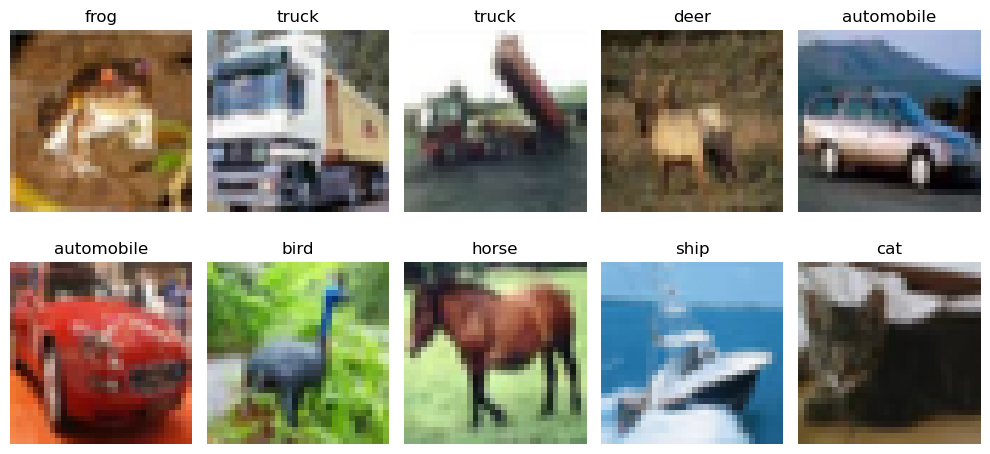

In [22]:
class_names = [
    'airplane','automobile','bird','cat','deer',
    'dog','frog','horse','ship','truck'
]

plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

# Preprocessing

In [23]:
# Normalize images
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [24]:
# Flatten images for ANN
x_train_flat = x_train.reshape(50000, 3072)
x_test_flat = x_test.reshape(10000, 3072)

print(x_train_flat.shape)
print(x_test_flat.shape)

(50000, 3072)
(10000, 3072)


# Standardization

In [25]:
mean = np.mean(x_train_flat, axis=0)
std = np.std(x_train_flat, axis=0) + 1e-7

x_train_flat = (x_train_flat - mean) / std
x_test_flat = (x_test_flat - mean) / std

# PART A: ANN MODEL

# Build ANN

In [26]:
ann_model = Sequential([

    Dense(2048,
          activation='relu',
          input_shape=(3072,)),

    BatchNormalization(),
    Dropout(0.4),

    Dense(1024, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),

    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(10, activation='softmax')
])

# Compile ANN

In [27]:
ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 2048)           │     6,293,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,065,738 (34.58 MB)

 Trainable params: 9,058,058 (34.55 MB)

 Non-trainable params: 7,680 (30.00 KB)

# Learning Rate Scheduler

In [28]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

# Train ANN

In [29]:
history_ann = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=40,
    batch_size=128,
    validation_split=0.2,
    callbacks=[lr_scheduler]
)

Epoch 1/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 36ms/step - accuracy: 0.2644 - loss: 2.2897 - val_accuracy: 0.4242 - val_loss: 1.6321 - learning_rate: 0.0010
Epoch 2/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.3989 - loss: 1.6874 - val_accuracy: 0.4573 - val_loss: 1.5197 - learning_rate: 0.0010
Epoch 3/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.4507 - loss: 1.5331 - val_accuracy: 0.4860 - val_loss: 1.4594 - learning_rate: 0.0010
Epoch 4/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.4837 - loss: 1.4509 - val_accuracy: 0.4936 - val_loss: 1.4302 - learning_rate: 0.0010
Epoch 5/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 43ms/step - accuracy: 0.5038 - loss: 1.3835 - val_accuracy: 0.5156 - val_loss: 1.3690 - learning_rate: 0.0010
Epoch 6/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 46ms/step - accuracy: 0.5183 - loss: 1.3404 - val_accuracy: 0.5184 - val_loss: 1.3517 - learning_rate: 0.0010
Epoch 7/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 14s 44ms/step - accuracy: 0.5390 - l

# Plot Training Curves

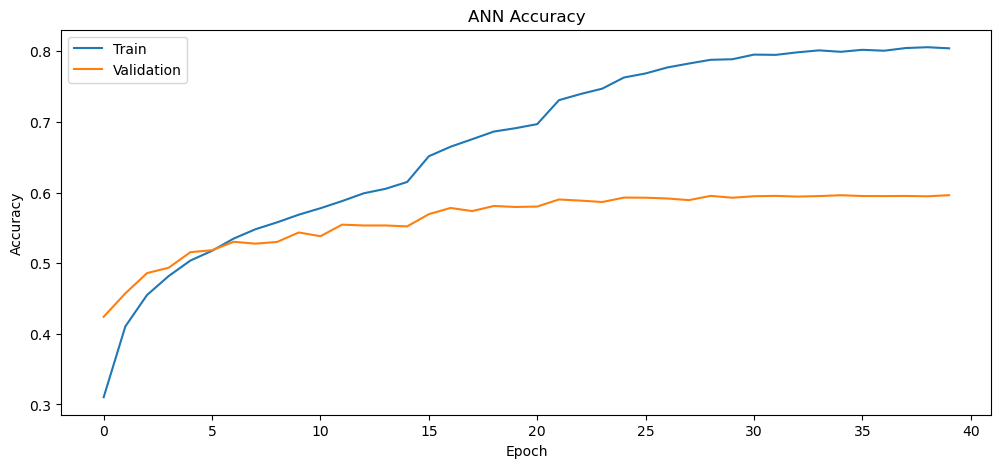

In [30]:
plt.figure(figsize=(12,5))

plt.plot(history_ann.history['accuracy'])
plt.plot(history_ann.history['val_accuracy'])

plt.title('ANN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train','Validation'])

plt.show()

# Evaluate on Test Data

In [31]:
test_loss, test_acc = ann_model.evaluate(
    x_test_flat,
    y_test
)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5909 - loss: 1.3467
Test Accuracy: 0.5877000093460083


# Predictions

In [32]:
predictions = ann_model.predict(x_test_flat)

predicted_classes = np.argmax(
    predictions,
    axis=1
)

print(predicted_classes[:10])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
[3 8 0 0 4 6 1 6 3 1]


# Classification Report

In [33]:
print(
    classification_report(
        y_test,
        predicted_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.68      0.65      0.66      1000
  automobile       0.72      0.68      0.70      1000
        bird       0.50      0.45      0.47      1000
         cat       0.39      0.44      0.41      1000
        deer       0.51      0.54      0.52      1000
         dog       0.50      0.46      0.48      1000
        frog       0.65      0.63      0.64      1000
       horse       0.66      0.65      0.65      1000
        ship       0.70      0.72      0.71      1000
       truck       0.61      0.66      0.63      1000

    accuracy                           0.59     10000
   macro avg       0.59      0.59      0.59     10000
weighted avg       0.59      0.59      0.59     10000



# Final Result Table

In [34]:
results = pd.DataFrame({
    "Model":["ANN"],
    "Test Accuracy":[test_acc]
})

results

,Model,Test Accuracy
0,ANN,0.5877


# PART B: CNN MODEL

# Verify Image Shape

In [35]:
print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


# Build CNN Model

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)

cnn_model = Sequential([
    
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        padding='same',
        input_shape=(32,32,3)
    ),
    
    BatchNormalization(),
    
    Conv2D(
        filters=32,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),
    
    MaxPooling2D(pool_size=(2,2)),
    
    Dropout(0.25),
    
    
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),
    
    BatchNormalization(),
    
    Conv2D(
        filters=64,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),
    
    MaxPooling2D(pool_size=(2,2)),
    
    Dropout(0.25),
    
    
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),
    
    BatchNormalization(),
    
    Conv2D(
        filters=128,
        kernel_size=(3,3),
        activation='relu',
        padding='same'
    ),
    
    MaxPooling2D(pool_size=(2,2)),
    
    Dropout(0.25),
    
    
    Flatten(),
    
    Dense(512, activation='relu'),
    
    BatchNormalization(),
    
    Dropout(0.5),
    
    Dense(10, activation='softmax')
])

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile CNN

In [37]:
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,344,170 (5.13 MB)

 Trainable params: 1,342,698 (5.12 MB)

 Non-trainable params: 1,472 (5.75 KB)

# Learning Rate Scheduler

In [38]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

# Early Stopping

In [39]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

# Train CNN

In [40]:
history_cnn = cnn_model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=128,
    validation_split=0.2,
    callbacks=[
        lr_scheduler,
        early_stop
    ]
)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 143ms/step - accuracy: 0.3291 - loss: 2.1003 - val_accuracy: 0.1888 - val_loss: 2.9486 - learning_rate: 0.0010
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 150ms/step - accuracy: 0.5511 - loss: 1.2719 - val_accuracy: 0.6416 - val_loss: 1.0158 - learning_rate: 0.0010
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 147ms/step - accuracy: 0.6404 - loss: 1.0177 - val_accuracy: 0.6904 - val_loss: 0.8788 - learning_rate: 0.0010
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 148ms/step - accuracy: 0.6921 - loss: 0.8637 - val_accuracy: 0.7034 - val_loss: 0.8664 - learning_rate: 0.0010
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 140ms/step - accuracy: 0.7273 - loss: 0.7760 - val_accuracy: 0.6979 - val_loss: 0.8690 - learning_rate: 0.0010
Epoch 6/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 147ms/step - accuracy: 0.7556 - loss: 0.7020 - val_accuracy: 0.7609 - val_loss: 0.6978 - learning_rate: 0.0010
Epoch 7/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 144ms/step - accuracy: 0.7

# Plot Accuracy Curve

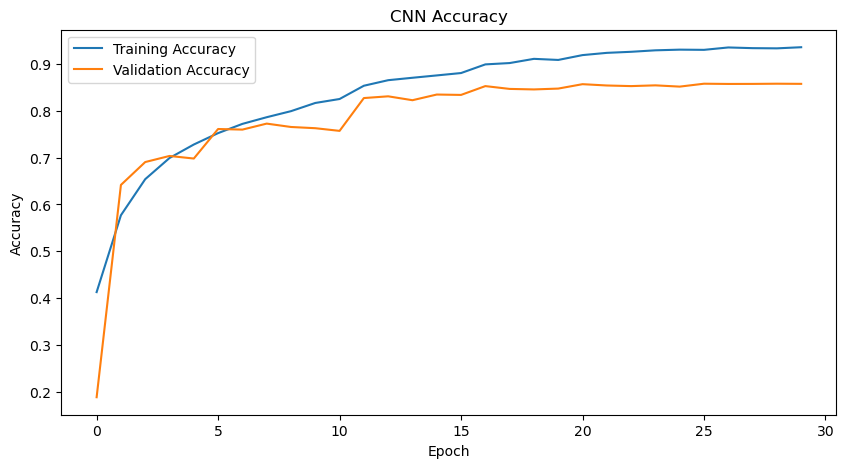

In [41]:
plt.figure(figsize=(10,5))

plt.plot(
    history_cnn.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_cnn.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy')

plt.legend()
plt.show()

# Plot Loss Curve

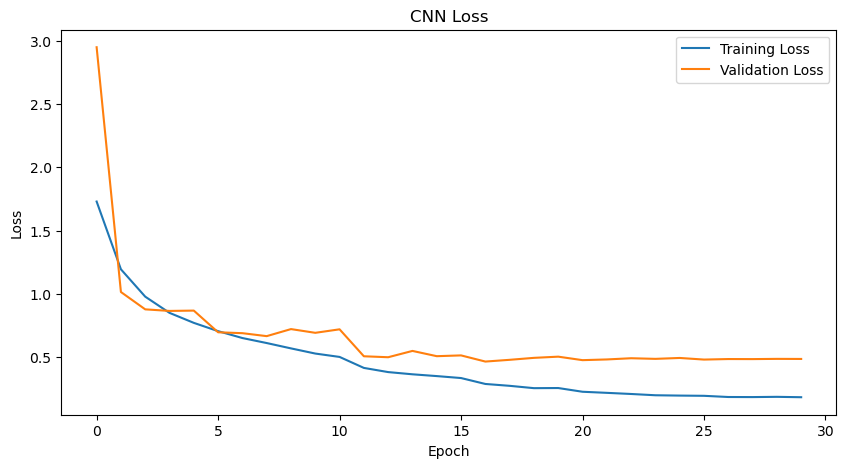

In [42]:
plt.figure(figsize=(10,5))

plt.plot(
    history_cnn.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_cnn.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('CNN Loss')

plt.legend()
plt.show()

# Evaluate CNN

In [43]:
cnn_loss, cnn_acc = cnn_model.evaluate(
    x_test,
    y_test
)

print("CNN Test Accuracy:", cnn_acc)
print("CNN Test Loss:", cnn_loss)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8457 - loss: 0.5167
CNN Test Accuracy: 0.8496000170707703
CNN Test Loss: 0.5079464912414551


# Generate Predictions

In [44]:
cnn_predictions = cnn_model.predict(x_test)

cnn_pred_classes = np.argmax(
    cnn_predictions,
    axis=1
)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


# Classification Report

In [45]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        cnn_pred_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    airplane       0.86      0.86      0.86      1000
  automobile       0.93      0.91      0.92      1000
        bird       0.82      0.76      0.79      1000
         cat       0.72      0.68      0.70      1000
        deer       0.82      0.84      0.83      1000
         dog       0.80      0.79      0.79      1000
        frog       0.86      0.91      0.89      1000
       horse       0.89      0.89      0.89      1000
        ship       0.91      0.93      0.92      1000
       truck       0.88      0.93      0.90      1000

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



# Confusion Matrix

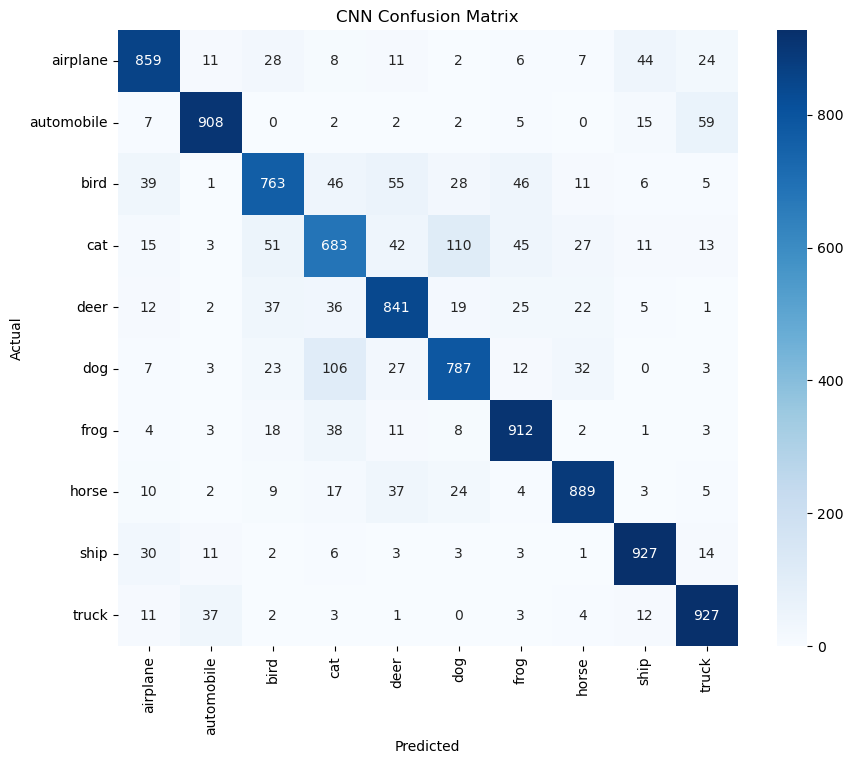

In [46]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(
    y_test,
    cnn_pred_classes
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")

plt.show()

# Save CNN Model

In [47]:
cnn_model.save("cifar10_cnn_model.h5")

print("CNN Model Saved Successfully")

CNN Model Saved Successfully
